In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.cluster import KMeans
import json, os

np.random.seed(42)

In [11]:
n = 200
students = pd.DataFrame({
    "student_id": range(1, n+1),
    "name": [f"Student_{i}" for i in range(1, n+1)],
    "class": np.random.choice(["10A","10B","10C"], size=n),
    "comprehension": np.random.randint(50,100,n),
    "attention": np.random.randint(50,100,n),
    "focus": np.random.randint(50,100,n),
    "retention": np.random.randint(50,100,n),
    "assessment_score": np.random.randint(40,100,n),
    "engagement_time": np.random.randint(30,80,n),
})
students.to_csv("../data/sample_students.csv", index=False)
students.head()

,student_id,name,class,comprehension,attention,focus,retention,assessment_score,engagement_time
0,1,Student_1,10C,98,84,68,68,94,58
1,2,Student_2,10A,98,99,98,66,87,37
2,3,Student_3,10C,61,74,85,70,43,34
3,4,Student_4,10C,88,73,61,63,69,58
4,5,Student_5,10A,51,62,90,58,50,76


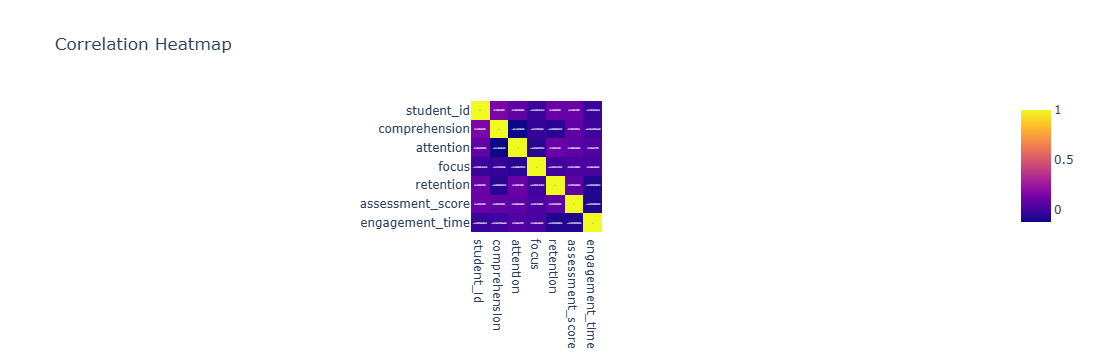

In [12]:
corr = students.corr(numeric_only=True)
fig = px.imshow(corr, text_auto=True, title="Correlation Heatmap")
fig.show()


In [14]:
students.head()


,student_id,name,class,comprehension,attention,focus,retention,assessment_score,engagement_time
0,1,Student_1,10C,98,84,68,68,94,58
1,2,Student_2,10A,98,99,98,66,87,37
2,3,Student_3,10C,61,74,85,70,43,34
3,4,Student_4,10C,88,73,61,63,69,58
4,5,Student_5,10A,51,62,90,58,50,76


In [16]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

X = students[["comprehension","attention","focus","retention","engagement_time"]]
y = students["assessment_score"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train,y_train)

y_pred = model.predict(X_test)
print("R²:", r2_score(y_test,y_pred))
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
print("RMSE:", rmse)

R²: -0.1660715487826605
RMSE: 21.01677871368493


In [18]:
features = students[["comprehension","attention","focus","retention","assessment_score"]]
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
students["persona"] = kmeans.fit_predict(features)


In [ ]:
import os

export_path = "../dashboard/public/data/students.json"
os.makedirs(os.path.dirname(export_path), exist_ok=True)
students.to_json(export_path, orient="records")
